In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_df = pd.read_csv('/content/Cap_Training_Data_2025.csv')
test_df = pd.read_csv('/content/Cap_Test_Data_2025.csv')
sample_submission = pd.read_csv('/content/Cap_Sample_Submission_2025.csv')

In [ ]:
train_df.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [ ]:
train_df.tail()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
53510,11153511,skoda,octavia,Delhi,29334.0,Fourth & Above,2023.0,2,1598,77.0,NaN,4,man,4.0,5.0,diesel,1342996.50
53511,11153512,skoda,octavia,Bangalore,223631.0,Fourth & Above,2018.0,7,1900,77.0,NaN,8,man,5.0,5.0,diesel,510732.75
53512,11153513,bmw,x1,Pune,25500.0,Third,2024.0,1,1995,105.0,NaN,4,auto,4.0,5.0,diesel,2008123.50
53513,11153514,toyota,avensis,Jaipur,1195500.0,Third,2020.0,5,11950,93.0,compact,5,man,NaN,NaN,diesel,874352.25
53514,11153515,bmw,x5,Kochi,142000.0,First,2017.0,8,2993,173.0,NaN,4,auto,5.0,5.0,diesel,1576610.25


In [ ]:
train_df.shape

(53515, 17)

In [ ]:
test_df.shape

(5615, 16)

In [ ]:
sample_submission.head()

,ID,Price
0,21100001,375147.00
1,21100002,1193368.50
2,21100003,1523871.00
3,21100004,2180268.00
4,21100005,2704149.75


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  object 
 2   model                53515 non-null  object 
 3   Location             53509 non-null  object 
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  object 
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   object 
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  object 
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null 

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5615 entries, 0 to 5614
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5615 non-null   int64  
 1   Maker                5615 non-null   object 
 2   model                5615 non-null   object 
 3   Location             5615 non-null   object 
 4   Distance             5487 non-null   float64
 5   Owner Type           5615 non-null   object 
 6   manufacture_year     5615 non-null   int64  
 7   Age of car           5615 non-null   int64  
 8   engine_displacement  5615 non-null   int64  
 9   engine_power         5447 non-null   float64
 10  body_type            422 non-null    object 
 11  Vroom Audit Rating   5615 non-null   int64  
 12  transmission         5615 non-null   object 
 13  door_count           4809 non-null   float64
 14  seat_count           4724 non-null   float64
 15  fuel_type            5615 non-null   o

In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,53515.0,1.112676e+07,15448.594165,11100001.0,11113379.50,11126758.00,1.114014e+07,11153515.00
Distance,52304.0,9.454626e+04,275561.716141,0.0,15490.00,65520.00,1.356410e+05,9899800.00
manufacture_year,53513.0,2.019408e+03,4.650367,1943.0,2017.00,2020.00,2.023000e+03,2025.00
Age of car,53515.0,5.591946e+00,4.650281,0.0,2.00,5.00,8.000000e+00,82.00
engine_displacement,53515.0,1.904049e+03,1496.564596,14.0,1395.00,1896.00,1.995000e+03,32000.00
engine_power,52076.0,1.004483e+02,45.330622,10.0,73.00,91.00,1.250000e+02,896.00
Vroom Audit Rating,53515.0,5.998374e+00,1.418336,4.0,5.00,6.00,7.000000e+00,8.00
door_count,45981.0,3.973011e+00,0.740659,1.0,4.00,4.00,4.000000e+00,6.00
seat_count,45004.0,4.886099e+00,0.564332,1.0,5.00,5.00,5.000000e+00,9.00
Price,53515.0,1.098084e+06,844156.530729,3.0,505181.25,885455.25,1.477829e+06,22120775.25


In [ ]:
train_df.describe(include="object").T

,count,unique,top,freq
Maker,53515,8,skoda,21563
model,53515,23,octavia,12619
Location,53509,11,Coimbatore,4974
Owner Type,53515,4,First,13406
body_type,4136,2,compact,4127
transmission,53515,2,man,36734
fuel_type,53515,2,diesel,27559


In [ ]:
# Missing Values
print(train_df.isnull().sum())

ID                         0
Maker                      0
model                      0
Location                   6
Distance                1211
Owner Type                 0
manufacture_year           2
Age of car                 0
engine_displacement        0
engine_power            1439
body_type              49379
Vroom Audit Rating         0
transmission               0
door_count              7534
seat_count              8511
fuel_type                  0
Price                      0
dtype: int64


In [ ]:
#To check duplicate values.
train_df.duplicated().sum()

np.int64(0)

In [ ]:
print(test_df.isnull().sum())

ID                        0
Maker                     0
model                     0
Location                  0
Distance                128
Owner Type                0
manufacture_year          0
Age of car                0
engine_displacement       0
engine_power            168
body_type              5193
Vroom Audit Rating        0
transmission              0
door_count              806
seat_count              891
fuel_type                 0
dtype: int64


In [ ]:
# separate Numerical & categorical Columns
numerical_columns = train_df.select_dtypes(include = ['int64','float64']).columns.tolist()
categorical_columns = train_df.select_dtypes(include='object').columns.tolist()

In [ ]:
# Remove target variable
if "Price" in numerical_columns:
    numerical_columns.remove("Price")

In [ ]:
train_df[numerical_columns].isnull().sum()

,0
ID,0
Distance,1211
manufacture_year,2
Age of car,0
engine_displacement,0
engine_power,1439
Vroom Audit Rating,0
door_count,7534
seat_count,8511


In [ ]:
for col in numerical_columns:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    test_df[col].fillna(train_df[col].median(), inplace=True)

In [ ]:
train_df[categorical_columns].isnull().sum()

,0
Maker,0
model,0
Location,6
Owner Type,0
body_type,49379
transmission,0
fuel_type,0


In [ ]:
for col in categorical_columns:
    mode_value = train_df[col].mode()[0]
    train_df[col].fillna(mode_value, inplace=True)
    test_df[col].fillna(mode_value, inplace=True)

In [ ]:
train_df.isnull().sum()

,0
ID,0
Maker,0
model,0
Location,0
Distance,0
Owner Type,0
manufacture_year,0
Age of car,0
engine_displacement,0
engine_power,0


In [ ]:
test_df.isnull().sum()

,0
ID,0
Maker,0
model,0
Location,0
Distance,0
Owner Type,0
manufacture_year,0
Age of car,0
engine_displacement,0
engine_power,0


In [ ]:
train_df.dtypes

,0
ID,int64
Maker,object
model,object
Location,object
Distance,float64
Owner Type,object
manufacture_year,float64
Age of car,int64
engine_displacement,int64
engine_power,float64


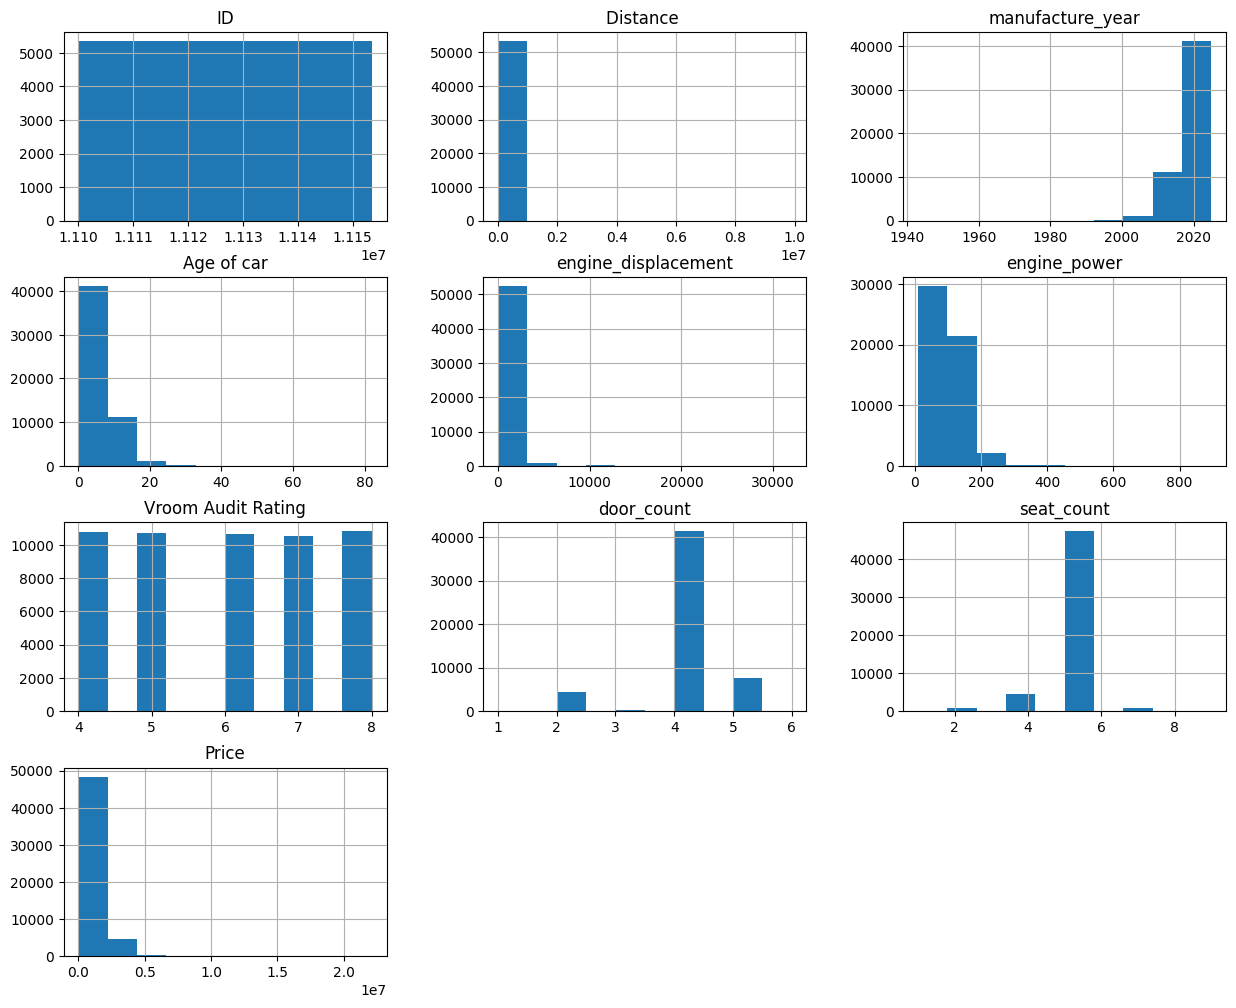

In [ ]:
 # univariate Analysis
train_df.hist(figsize = (15,12))
plt.show()

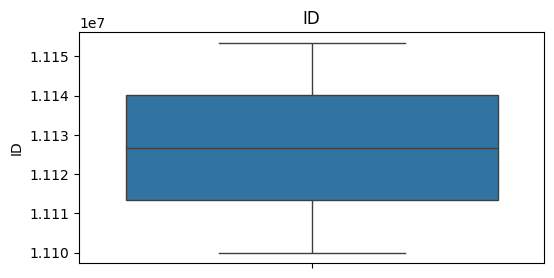

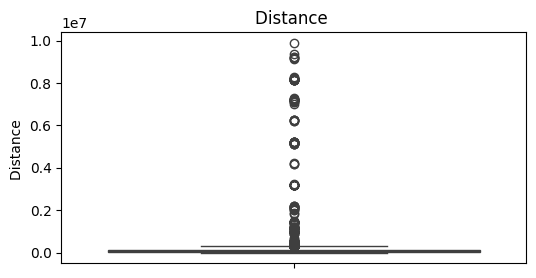

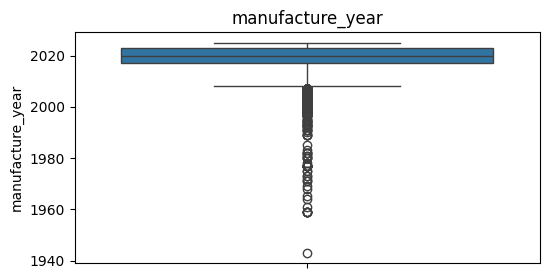

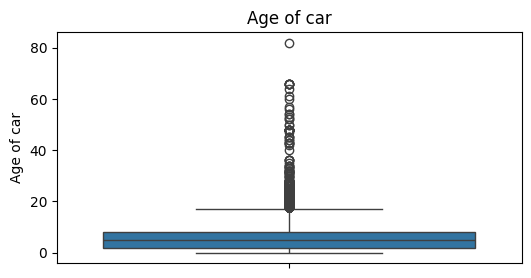

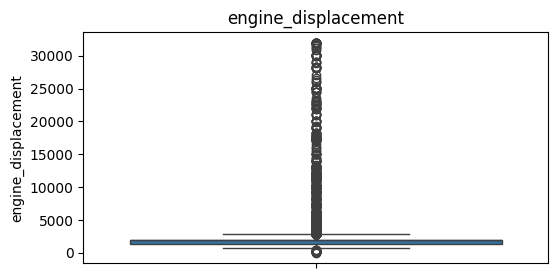

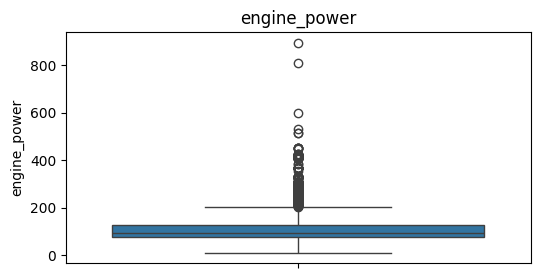

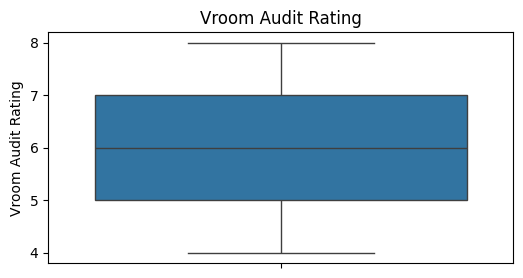

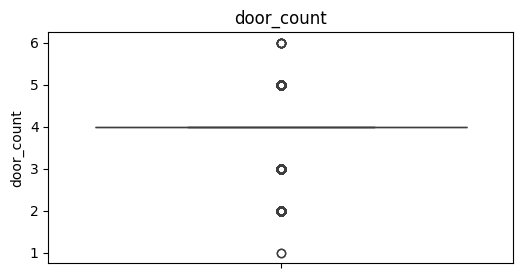

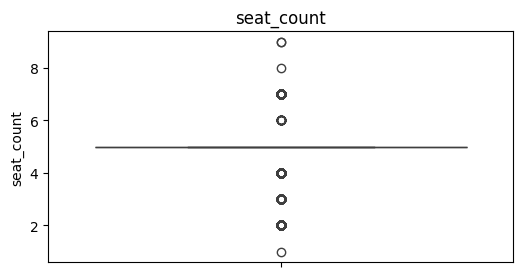

In [ ]:
# box plot
for col in numerical_columns:
  plt.figure(figsize = (6,3))
  sns.boxplot(train_df[col])
  plt.title(col)
  plt.show()

In [ ]:
exclude_cols = ['ID','Vroom Audit Rating']
num_cols = [col for col in numerical_columns if col not in exclude_cols] # Deleting extra columns..
print(num_cols)

['Distance ', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'door_count', 'seat_count']


In [ ]:
# Outlier Treatment
for col in num_cols:
  Q1 = train_df[col].quantile(0.25)
  Q3 = train_df[col].quantile(0.75)

  IQR = Q3-Q1

  lower_range = Q1 - 1.5*IQR
  upper_range = Q3 + 1.5*IQR

  train_df[col] = np.where(train_df[col] > upper_range, upper_range, train_df[col])
  train_df[col] = np.where(train_df[col] < lower_range, lower_range, train_df[col])

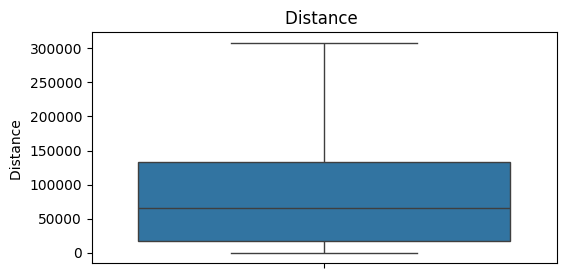

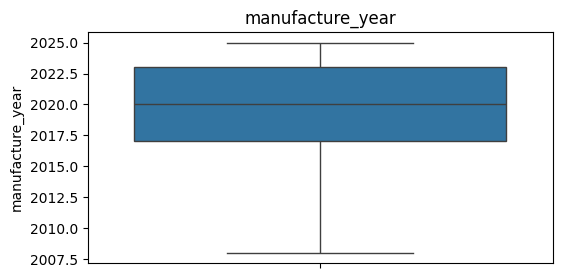

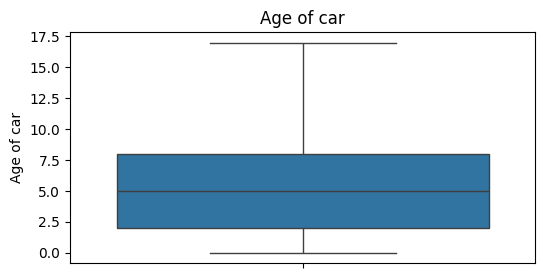

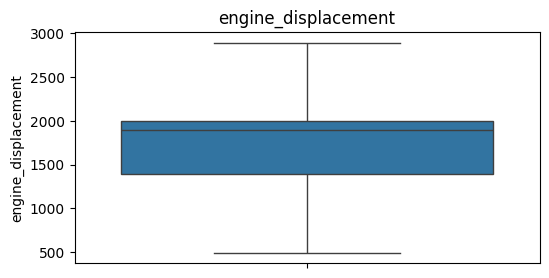

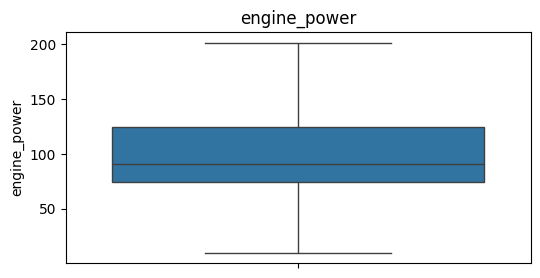

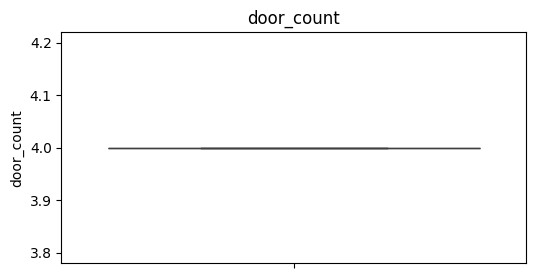

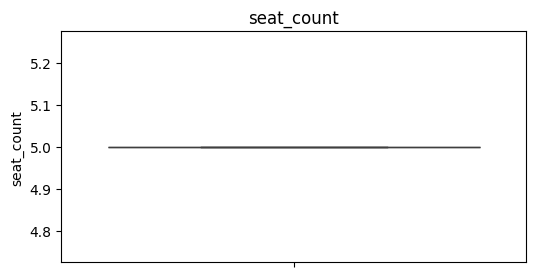

In [ ]:
# verifying
for col in num_cols:
  plt.figure(figsize =(6,3))
  sns.boxplot(train_df[col])
  plt.title(col)
  plt.show()

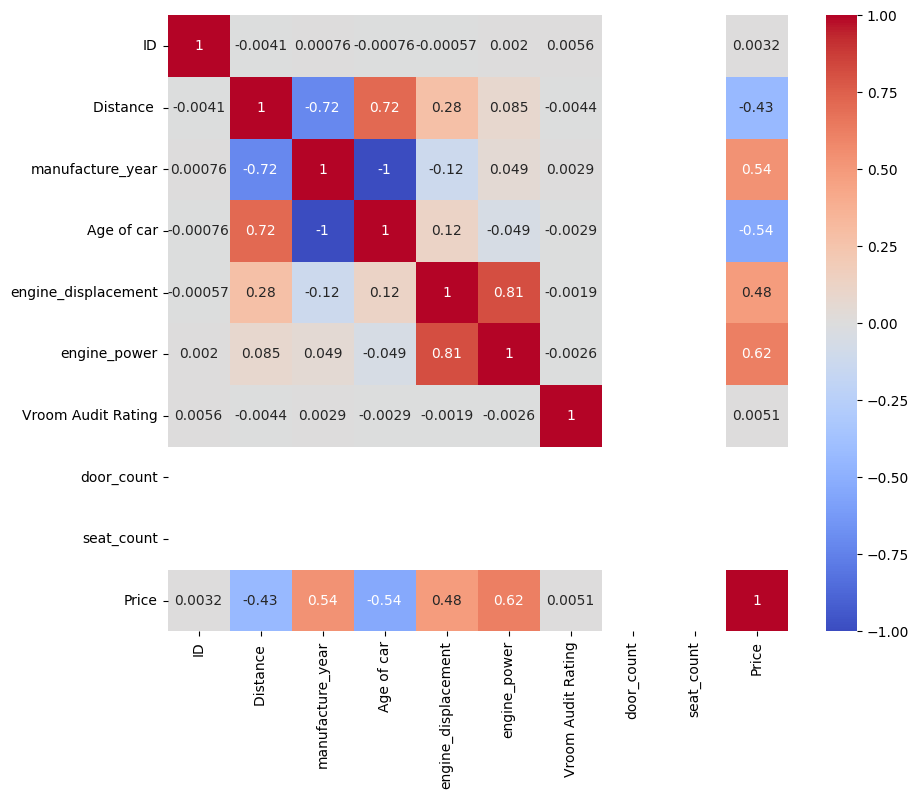

In [ ]:
# Correlation Analysis
corr = train_df.corr(numeric_only=True)
plt.figure(figsize =(10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

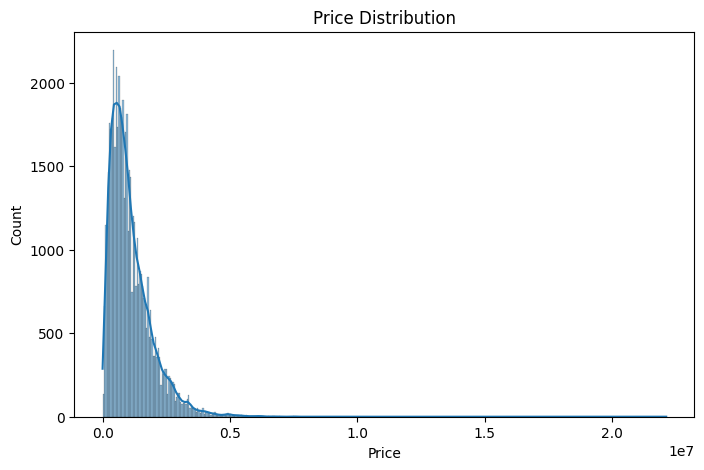

In [ ]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

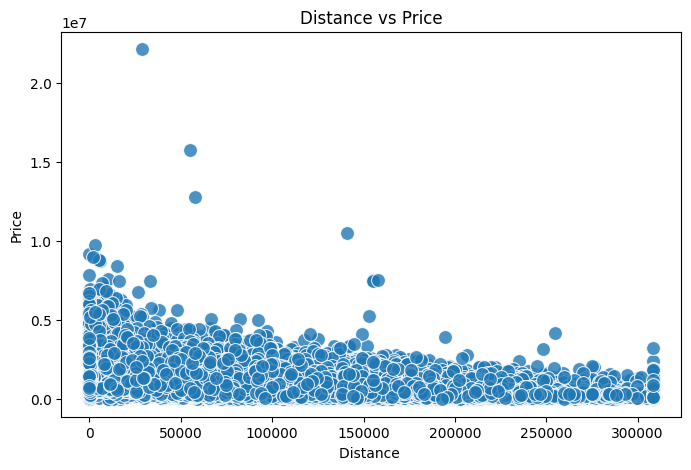

In [ ]:
# Distance vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x="Distance ",y="Price",data=train_df, s= 100, alpha = 0.8)
plt.title("Distance vs Price")
plt.show()

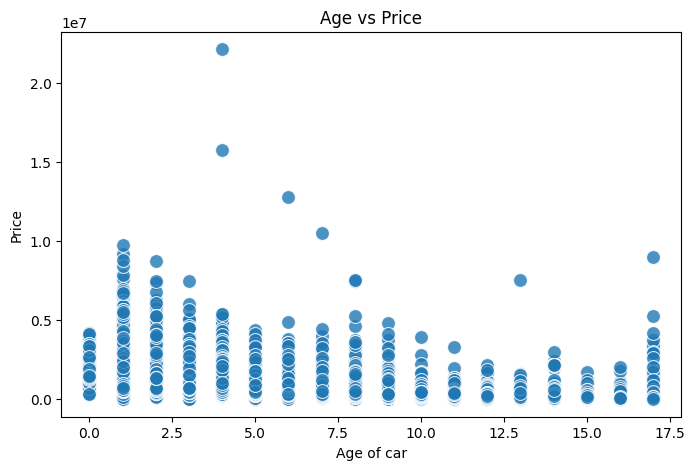

In [ ]:
# Age vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age of car",y="Price",data=train_df, s= 100, alpha = 0.8)
plt.title("Age vs Price")
plt.show()

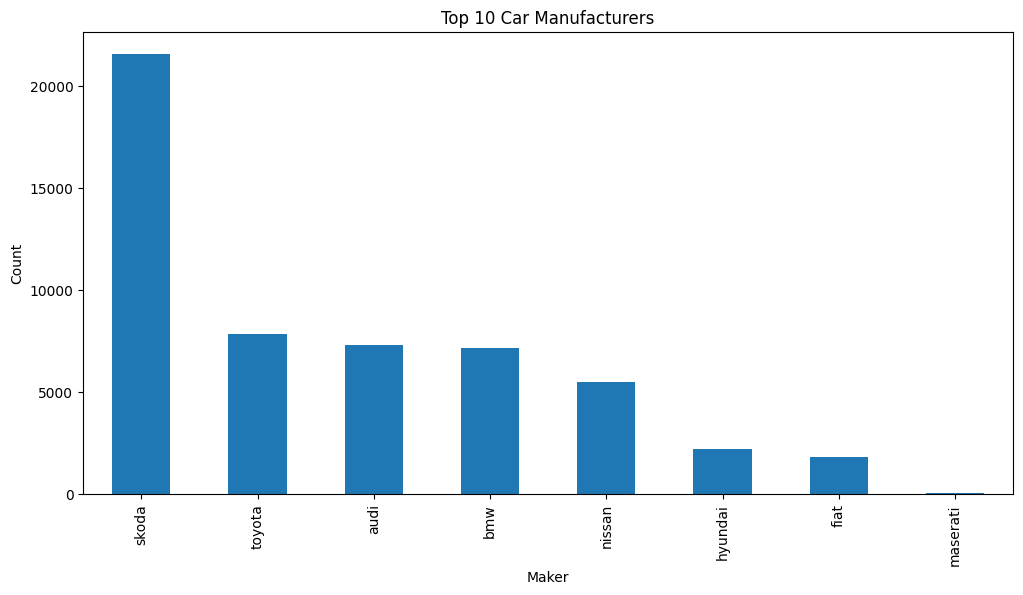

In [ ]:
# categorical analysis
plt.figure(figsize=(12,6))
train_df["Maker"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Car Manufacturers")
plt.ylabel("Count")
plt.show()

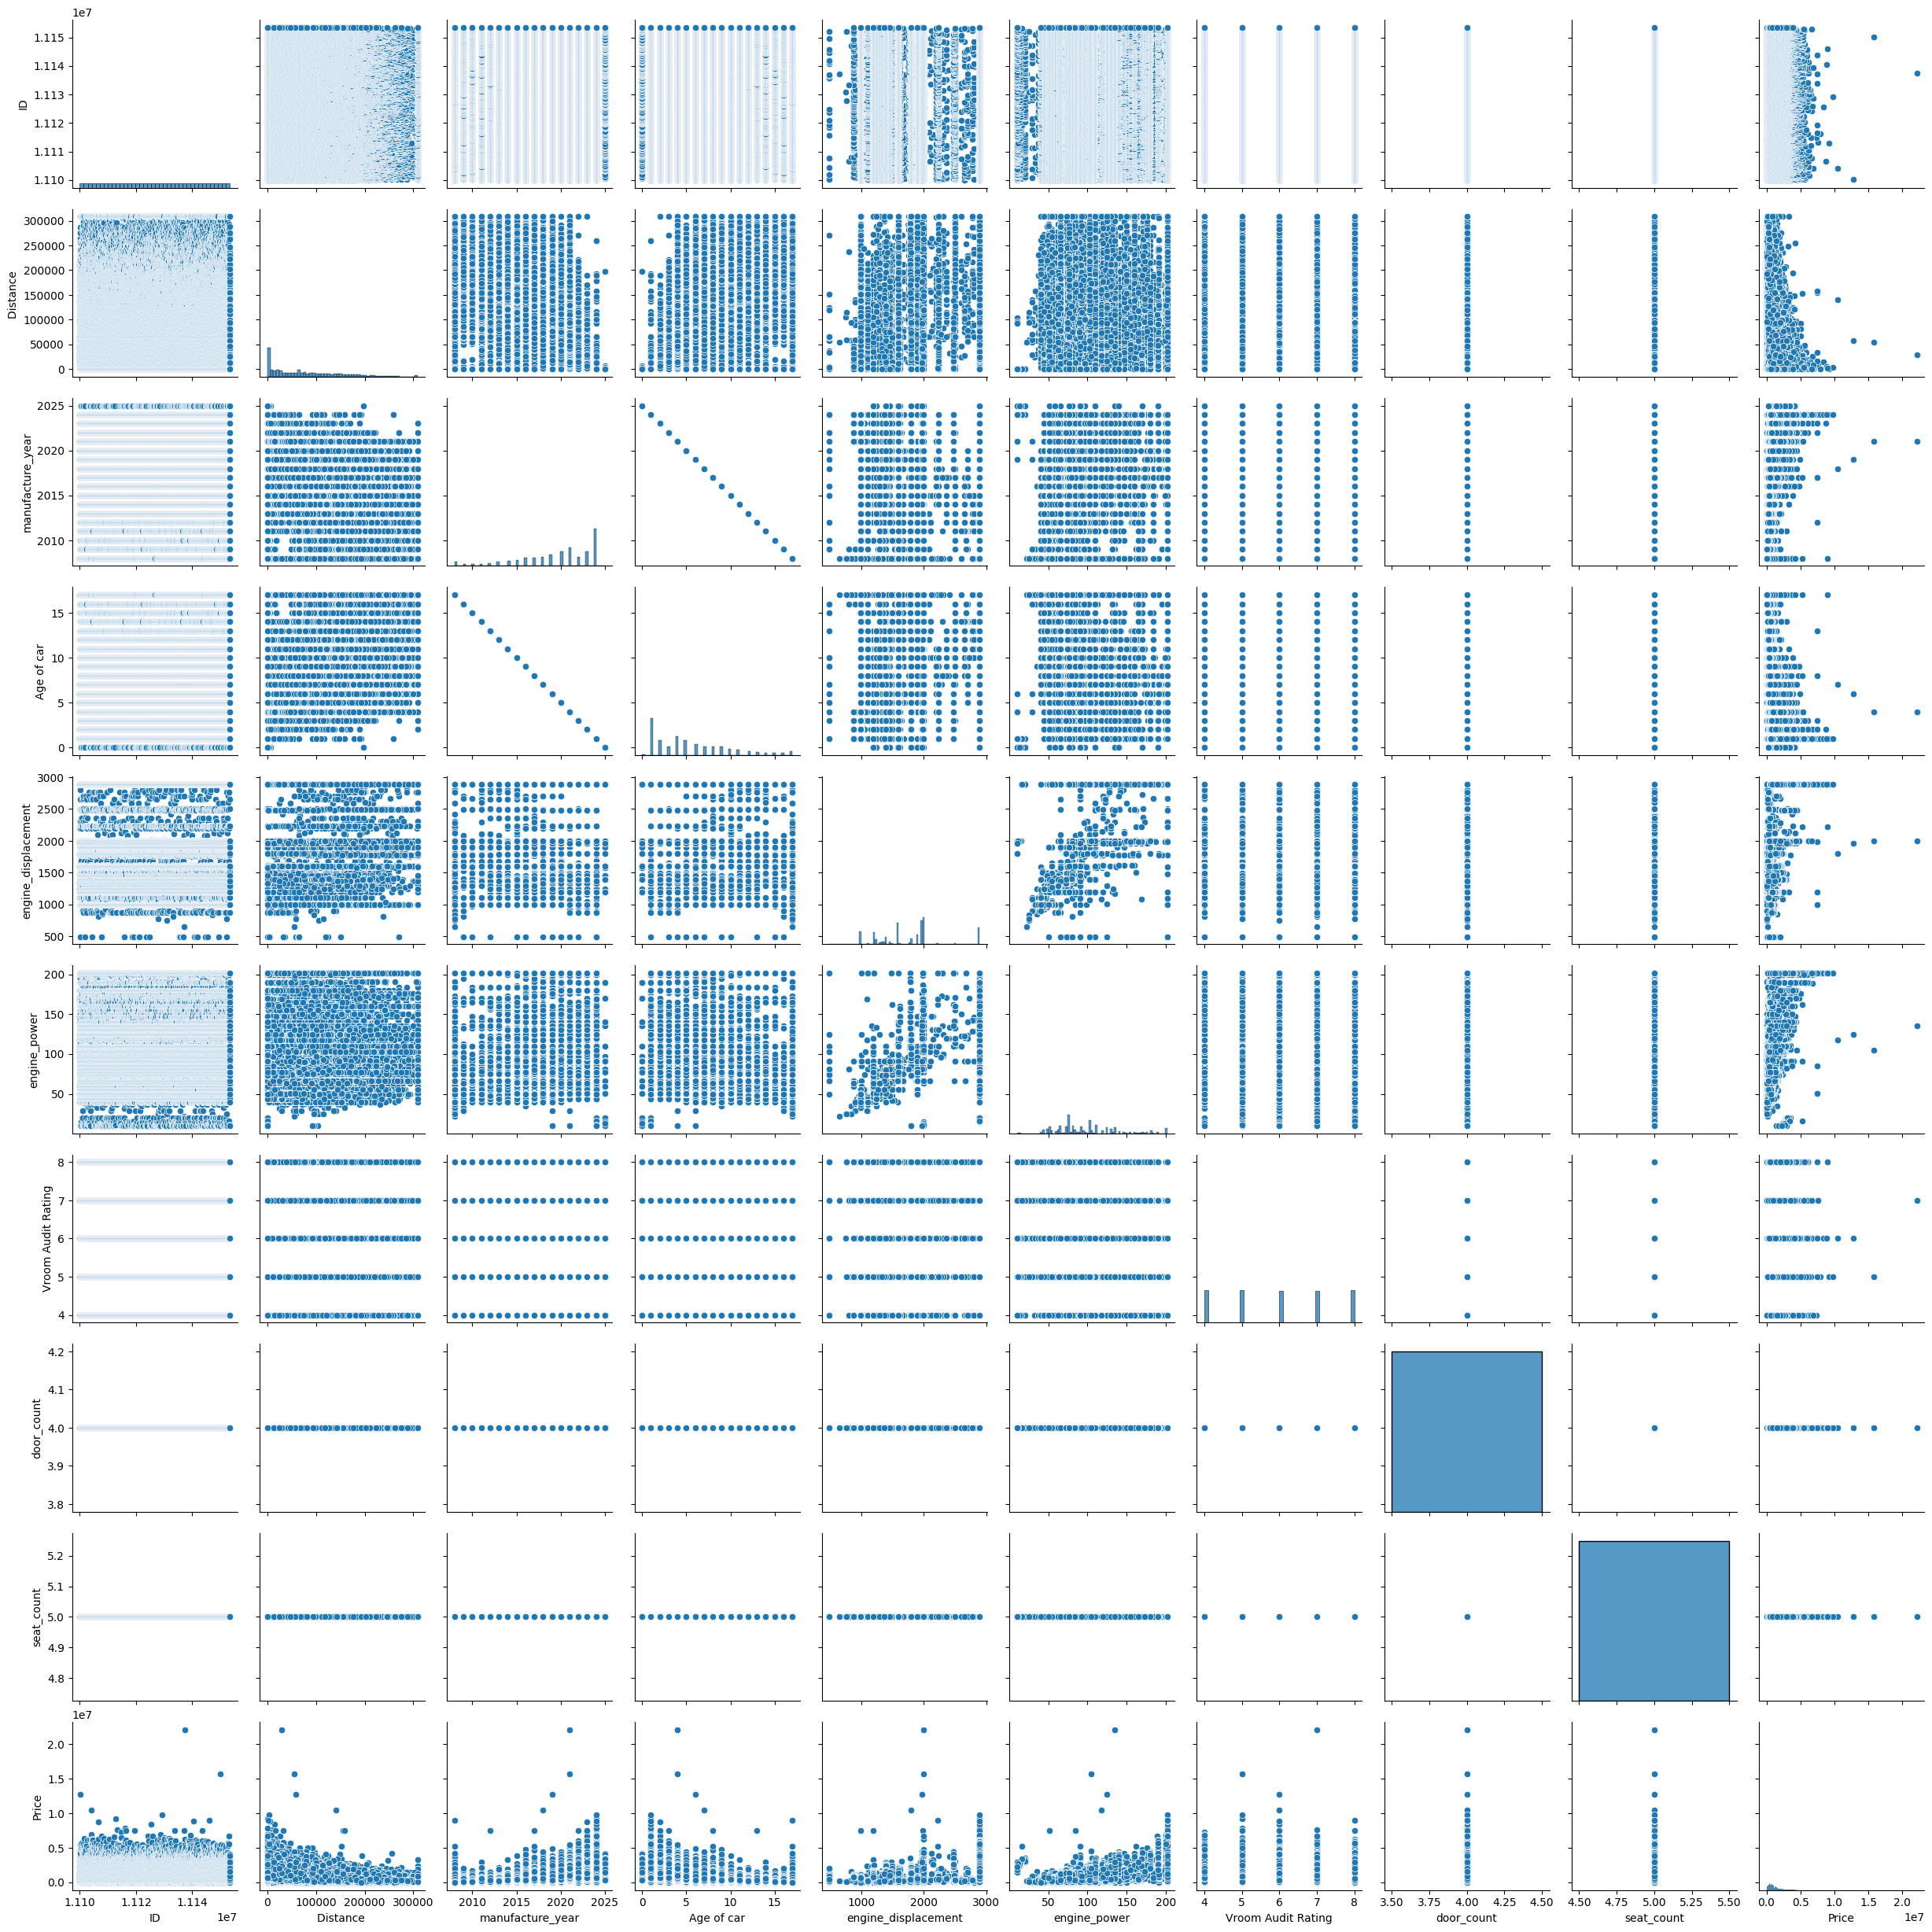

In [ ]:
# Multivariate Data
sns.pairplot(train_df)
plt.show()

In [ ]:
# Encoding
cat_cols = train_df.select_dtypes(include = ['object']).columns
print(cat_cols)

Index(['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission',
       'fuel_type'],
      dtype='object')


In [ ]:
# Lable Encoding
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le

In [ ]:
train_df.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,6,8,0,65520.0,2,2008.0,17.0,1964.0,147.0,0,8,1,4.0,5.0,1,543764.25
1,11100002,2,9,0,27750.0,3,2021.0,4.0,1242.0,51.0,0,6,1,4.0,5.0,1,401819.25
2,11100003,1,18,5,46000.0,3,2023.0,2.0,1995.0,105.0,0,7,0,4.0,5.0,0,2392855.50
3,11100004,5,6,9,43949.0,3,2020.0,5.0,1618.0,140.0,0,7,1,4.0,5.0,1,958606.50
4,11100005,1,20,6,59524.0,1,2021.0,4.0,2895.0,180.0,0,7,0,4.0,5.0,0,3085561.50


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(train_df)
scaled_df = pd.DataFrame(scaled_data, columns = train_df.columns)
scaled_df.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,-1.732018,0.670441,-0.525379,-1.586814,-0.224251,0.447065,-2.670615,2.670615,0.355180,1.205830,-0.012969,1.411263,0.675888,0.0,0.0,1.030417,-0.656661
1,-1.731954,-0.895167,-0.363222,-1.586814,-0.720792,1.340911,0.352647,-0.352647,-1.057021,-1.200821,-0.012969,0.001146,0.675888,0.0,0.0,1.030417,-0.824812
2,-1.731889,-1.286569,1.096195,-0.003060,-0.480869,1.340911,0.817764,-0.817764,0.415815,0.152920,-0.012969,0.706204,-1.479535,0.0,0.0,-0.970481,1.533820
3,-1.731824,0.279039,-0.849694,1.263943,-0.507833,1.340911,0.120088,-0.120088,-0.321581,1.030345,-0.012969,0.706204,0.675888,0.0,0.0,1.030417,-0.165228
4,-1.731760,-1.286569,1.420509,0.313691,-0.303077,-0.446781,0.352647,-0.352647,2.176177,2.033116,-0.012969,0.706204,-1.479535,0.0,0.0,-0.970481,2.354417


In [ ]:
# Test train split
from sklearn.model_selection import train_test_split
train_df = train_df.drop("ID", axis=1)
X = train_df.drop("Price", axis=1)
y = train_df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
# Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

In [ ]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9872805560475709
Testing Score: 0.926661889315026


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42,max_depth = 10,min_samples_split = 10, min_samples_leaf = 7)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)
print("Training Score:", train_score)
print("Testing Score:", test_score )

Training Score: 0.9270906854506463
Testing Score: 0.927913948439001


In [ ]:
# Grid Search
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1 )
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Training Score: 0.949903499624805
Testing Score: 0.9329925940546876


In [ ]:
# XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

model3 = XGBRegressor()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9317540509375672


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
# Prediction
y_pred = rf.predict(X_test)
# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.927913948439001
MAE: 123659.29635345154
MSE: 51301139168.90707
RMSE: 226497.5478209578


In [ ]:
import joblib
joblib.dump(rf, "car_price_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
from google.colab import files
files.download("car_price_model.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>